# Direct gradual.97 comparison across epsilon_ff for seed 00

Jupytext-compatible diagnostic.

This script intentionally ignores evolved NBODY snapshots and compares only
the stellar formation records written to gradual.97 for seed 00 across:

  epsilon_ff = 0.01, 0.03, 0.10, 0.30, 1.00

It asks:

1. How many SINGLE and BINARY formation events occur?
2. How many stellar components are introduced?
3. What is the total introduced stellar mass?
4. Are the same component NAME values present?
5. Are the same initial component masses present?
6. Are the same binary pairings present?
7. Do systems form in the same event order?
8. If not, how quickly do the sequences diverge?
9. Are the underlying IMF / mass distributions nevertheless statistically similar?
10. How do formation times scale with epsilon_ff?

This avoids any possible contamination from stellar-wind mass loss,
stellar evolution, dynamical exchanges, mergers, or later snapshot state.

Run directly:

    python compare_gradual_seed00_across_eff.py

Or convert to a notebook:

    jupytext --to notebook compare_gradual_seed00_across_eff.py

Outputs are written to:

    ./seed00_gradual_comparison_outputs/

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Any
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Configuration

In [2]:
ROOT = Path(
    "/standard/Tan_JC/backup_protoclusters/multiples/"
    "M3000new/sigma0p1/fiducial"
)

EFF_DIRS = {
    0.01: "sfe_ff001",
    0.03: "sfe_ff003",
    0.10: "sfe_ff010",
    0.30: "sfe_ff030",
    1.00: "sfe_ff100",
}

SEED = "00"
REFERENCE_EFF = 0.03

OUTPUT_DIR = Path.cwd() / "seed00_gradual_comparison_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MASS_ATOL = 1.0e-10
MASS_RTOL = 1.0e-8
TIME_ATOL = 1.0e-10

SAVE_FIGURES = True
SHOW_FIGURES = True

## Helpers

In [3]:
def simulation_path(eff: float) -> Path:
    path = ROOT / EFF_DIRS[eff] / SEED
    if not path.is_dir():
        raise FileNotFoundError(path)
    return path


def gradual_path(eff: float) -> Path:
    path = simulation_path(eff) / "gradual.97"
    if not path.is_file():
        raise FileNotFoundError(path)
    return path


def show_table(df: pd.DataFrame, n: int | None = None) -> None:
    if n is not None:
        df = df.head(n)

    try:
        from IPython.display import display
        display(df)
    except Exception:
        print(df.to_string(index=False))


def finish_figure(fig, filename: str) -> None:
    if SAVE_FIGURES:
        fig.savefig(
            OUTPUT_DIR / filename,
            dpi=220,
            bbox_inches="tight",
        )

    if SHOW_FIGURES:
        plt.show()
    else:
        plt.close(fig)


def masses_match(a, b) -> np.ndarray:
    return np.isclose(
        np.asarray(a, dtype=float),
        np.asarray(b, dtype=float),
        atol=MASS_ATOL,
        rtol=MASS_RTOL,
        equal_nan=True,
    )

## Parse gradual.97

The parser preserves exact file order.  Every SINGLE or BINARY line is one
formation event.

Expected formats, consistent with the previous converter code:

  SINGLE ... formation_time name mass ...

  BINARY ... formation_time primary secondary m1 m2 ... ecc period semi

Fields after the masses are not needed here.

In [4]:
def parse_gradual(
    path: Path,
    eff: float,
) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    event_index = 0

    with path.open() as handle:
        for line_number, line in enumerate(handle, start=1):
            stripped = line.strip()

            if not stripped:
                continue

            fields = stripped.split()

            # Skip headers such as "... TIME ..."
            if len(fields) < 2 or fields[1].upper() == "TIME":
                continue

            event_type = fields[0].upper()

            if event_type not in {"SINGLE", "BINARY"}:
                continue

            try:
                formation_time = float(fields[2])

                if event_type == "SINGLE":
                    primary_name = int(fields[3])
                    companion_name = -1

                    primary_mass = float(fields[4])
                    companion_mass = np.nan

                else:
                    primary_name = int(fields[3])
                    companion_name = int(fields[4])

                    primary_mass = float(fields[5])
                    companion_mass = float(fields[6])

            except (IndexError, ValueError, TypeError) as exc:
                raise RuntimeError(
                    f"Could not parse {path}, line {line_number}:\n"
                    f"{line.rstrip()}"
                ) from exc

            system_mass = (
                primary_mass
                if event_type == "SINGLE"
                else primary_mass + companion_mass
            )

            rows.append({
                "epsilon_ff": float(eff),
                "event_index": int(event_index),
                "source_line": int(line_number),
                "event_type": event_type,
                "formation_time_myr": float(formation_time),
                "primary_name": int(primary_name),
                "companion_name": int(companion_name),
                "primary_mass": float(primary_mass),
                "companion_mass": float(companion_mass),
                "system_mass": float(system_mass),
                "n_components": 1 if event_type == "SINGLE" else 2,
            })

            event_index += 1

    df = pd.DataFrame(rows)

    if df.empty:
        raise RuntimeError(
            f"No SINGLE/BINARY records found in {path}"
        )

    return df

## Expand formation events to one row per stellar component

This is the cleanest representation for testing whether the same physical
stars, identified by NAME, are ultimately introduced.

In [5]:
def component_catalog(events: pd.DataFrame) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []

    for event in events.itertuples(index=False):
        if event.event_type == "SINGLE":
            rows.append({
                "epsilon_ff": event.epsilon_ff,
                "event_index": int(event.event_index),
                "formation_time_myr": float(event.formation_time_myr),
                "name": int(event.primary_name),
                "initial_mass": float(event.primary_mass),
                "role": "single",
                "binary_partner": -1,
            })

        else:
            rows.append({
                "epsilon_ff": event.epsilon_ff,
                "event_index": int(event.event_index),
                "formation_time_myr": float(event.formation_time_myr),
                "name": int(event.primary_name),
                "initial_mass": float(event.primary_mass),
                "role": "binary_primary",
                "binary_partner": int(event.companion_name),
            })

            rows.append({
                "epsilon_ff": event.epsilon_ff,
                "event_index": int(event.event_index),
                "formation_time_myr": float(event.formation_time_myr),
                "name": int(event.companion_name),
                "initial_mass": float(event.companion_mass),
                "role": "binary_secondary",
                "binary_partner": int(event.primary_name),
            })

    df = pd.DataFrame(rows)

    if df["name"].duplicated().any():
        duplicates = (
            df.loc[df["name"].duplicated(keep=False), "name"]
            .value_counts()
            .sort_index()
        )

        print(
            "WARNING: some NAME values appear more than once in gradual.97."
        )
        print(duplicates.head(50))

    return df

## Load all five runs

In [6]:
events_by_eff: dict[float, pd.DataFrame] = {}
components_by_eff: dict[float, pd.DataFrame] = {}

for eff in EFF_DIRS:
    path = gradual_path(eff)

    print("=" * 80)
    print(f"epsilon_ff = {eff:.2f}")
    print(path)

    events = parse_gradual(path, eff)
    components = component_catalog(events)

    events_by_eff[eff] = events
    components_by_eff[eff] = components

    n_single = int((events["event_type"] == "SINGLE").sum())
    n_binary = int((events["event_type"] == "BINARY").sum())

    print(f"  formation events: {len(events)}")
    print(f"  SINGLE events:    {n_single}")
    print(f"  BINARY events:    {n_binary}")
    print(f"  components:       {len(components)}")
    print(
        f"  total mass:       "
        f"{components['initial_mass'].sum():.12g} Msun"
    )
    print(
        f"  NAME range:       "
        f"{components['name'].min()} -- "
        f"{components['name'].max()}"
    )

epsilon_ff = 0.01
/standard/Tan_JC/backup_protoclusters/multiples/M3000new/sigma0p1/fiducial/sfe_ff001/00/gradual.97
  formation events: 2766
  SINGLE events:    1392
  BINARY events:    1374
  components:       4140
  total mass:       1466.86244684 Msun
  NAME range:       151 -- 4290
epsilon_ff = 0.03
/standard/Tan_JC/backup_protoclusters/multiples/M3000new/sigma0p1/fiducial/sfe_ff003/00/gradual.97


  formation events: 2720
  SINGLE events:    1357
  BINARY events:    1363
  components:       4083
  total mass:       1459.81512361 Msun
  NAME range:       151 -- 4233


epsilon_ff = 0.10
/standard/Tan_JC/backup_protoclusters/multiples/M3000new/sigma0p1/fiducial/sfe_ff010/00/gradual.97
  formation events: 2431
  SINGLE events:    1216
  BINARY events:    1215
  components:       3646
  total mass:       1469.28902218 Msun
  NAME range:       151 -- 3796
epsilon_ff = 0.30
/standard/Tan_JC/backup_protoclusters/multiples/M3000new/sigma0p1/fiducial/sfe_ff030/00/gradual.97


  formation events: 2373
  SINGLE events:    1188
  BINARY events:    1185
  components:       3558
  total mass:       1398.86983459 Msun
  NAME range:       151 -- 3708
epsilon_ff = 1.00
/standard/Tan_JC/backup_protoclusters/multiples/M3000new/sigma0p1/fiducial/sfe_ff100/00/gradual.97
  formation events: 2249
  SINGLE events:    1126
  BINARY events:    1123
  components:       3372
  total mass:       1454.01782984 Msun
  NAME range:       151 -- 3522


## Global inventory summary

In [7]:
inventory_rows = []

for eff, events in events_by_eff.items():
    components = components_by_eff[eff]

    singles = events["event_type"] == "SINGLE"
    binaries = events["event_type"] == "BINARY"

    inventory_rows.append({
        "epsilon_ff": eff,
        "n_events": len(events),
        "n_single_events": int(singles.sum()),
        "n_binary_events": int(binaries.sum()),
        "n_components": len(components),
        "n_unique_names": components["name"].nunique(),
        "n_duplicate_component_rows": int(
            len(components) - components["name"].nunique()
        ),
        "total_initial_mass_msun": float(
            components["initial_mass"].sum()
        ),
        "median_component_mass_msun": float(
            components["initial_mass"].median()
        ),
        "mean_component_mass_msun": float(
            components["initial_mass"].mean()
        ),
        "min_component_mass_msun": float(
            components["initial_mass"].min()
        ),
        "max_component_mass_msun": float(
            components["initial_mass"].max()
        ),
        "first_formation_time_myr": float(
            events["formation_time_myr"].min()
        ),
        "last_formation_time_myr": float(
            events["formation_time_myr"].max()
        ),
    })

df_inventory = pd.DataFrame(inventory_rows)

print("\nGLOBAL INVENTORY")
show_table(df_inventory)

df_inventory.to_csv(
    OUTPUT_DIR / "global_inventory.csv",
    index=False,
)


GLOBAL INVENTORY


,epsilon_ff,n_events,n_single_events,n_binary_events,n_components,n_unique_names,n_duplicate_component_rows,total_initial_mass_msun,median_component_mass_msun,mean_component_mass_msun,min_component_mass_msun,max_component_mass_msun,first_formation_time_myr,last_formation_time_myr
0,0.01,2766,1392,1374,4140,4140,0,1466.862447,0.120812,0.354315,0.010083,32.172083,1.585947e-08,17.482669
1,0.03,2720,1357,1363,4083,4083,0,1459.815124,0.119240,0.357535,0.010027,25.388293,1.585946e-08,6.250554
2,0.10,2431,1216,1215,3646,3646,0,1469.289022,0.119281,0.402987,0.010038,70.965048,1.605021e-08,2.121228
3,0.30,2373,1188,1185,3558,3558,0,1398.869835,0.119364,0.393162,0.010080,94.857453,1.637956e-08,0.794735
4,1.00,2249,1126,1123,3372,3372,0,1454.017830,0.116548,0.431203,0.010057,85.641140,1.627234e-08,0.184053


## Compare NAME sets directly

This ignores masses, binaries, and event order and asks only:

"Are the same stellar identifiers ultimately introduced?"

In [8]:
reference_components = components_by_eff[REFERENCE_EFF]

reference_names = set(
    reference_components["name"].astype(int)
)

name_set_rows = []
name_difference_tables = []

for eff, components in components_by_eff.items():
    names = set(components["name"].astype(int))

    missing_from_target = sorted(reference_names - names)
    extra_in_target = sorted(names - reference_names)

    name_set_rows.append({
        "epsilon_ff": eff,
        "n_reference_names": len(reference_names),
        "n_target_names": len(names),
        "n_shared_names": len(reference_names & names),
        "n_missing_from_target": len(missing_from_target),
        "n_extra_in_target": len(extra_in_target),
        "same_name_set": bool(names == reference_names),
        "jaccard_name_similarity": (
            len(reference_names & names)
            / len(reference_names | names)
            if reference_names | names
            else 1.0
        ),
    })

    if missing_from_target:
        name_difference_tables.append(
            pd.DataFrame({
                "epsilon_ff": eff,
                "difference_type": "missing_from_target",
                "name": missing_from_target,
            })
        )

    if extra_in_target:
        name_difference_tables.append(
            pd.DataFrame({
                "epsilon_ff": eff,
                "difference_type": "extra_in_target",
                "name": extra_in_target,
            })
        )

df_name_sets = pd.DataFrame(name_set_rows)

if name_difference_tables:
    df_name_differences = pd.concat(
        name_difference_tables,
        ignore_index=True,
    )
else:
    df_name_differences = pd.DataFrame(
        columns=[
            "epsilon_ff",
            "difference_type",
            "name",
        ]
    )

print("\nNAME-SET COMPARISON AGAINST epsilon_ff=0.03")
show_table(df_name_sets)

df_name_sets.to_csv(
    OUTPUT_DIR / "name_set_comparison.csv",
    index=False,
)

df_name_differences.to_csv(
    OUTPUT_DIR / "name_set_differences.csv",
    index=False,
)


NAME-SET COMPARISON AGAINST epsilon_ff=0.03


,epsilon_ff,n_reference_names,n_target_names,n_shared_names,n_missing_from_target,n_extra_in_target,same_name_set,jaccard_name_similarity
0,0.01,4083,4140,4083,0,57,False,0.986232
1,0.03,4083,4083,4083,0,0,True,1.000000
2,0.10,4083,3646,3646,437,0,False,0.892971
3,0.30,4083,3558,3558,525,0,False,0.871418
4,1.00,4083,3372,3372,711,0,False,0.825863


## Compare shared component NAME values

For stars that occur in both the reference and target runs, test:

- initial mass
- multiplicity role
- binary partner
- formation event index

This is much more informative than a single all-or-nothing verdict.

In [9]:
def unique_component_view(df: pd.DataFrame) -> pd.DataFrame:
    """
    Return one row per NAME if possible.

    If a NAME appears multiple times, keep the first record but retain a count
    column so this issue remains visible in the comparison.
    """
    counts = (
        df.groupby("name")
        .size()
        .rename("occurrence_count")
    )

    first = (
        df.sort_values(
            ["name", "event_index"],
            kind="stable",
        )
        .drop_duplicates("name", keep="first")
        .set_index("name")
    )

    return first.join(counts)


reference_unique = unique_component_view(reference_components)

component_match_rows = []
component_detail_tables = []

for eff, components in components_by_eff.items():
    target_unique = unique_component_view(components)

    merged = (
        reference_unique.add_suffix("_ref")
        .join(
            target_unique.add_suffix("_target"),
            how="outer",
        )
        .reset_index()
    )

    in_ref = merged["initial_mass_ref"].notna()
    in_target = merged["initial_mass_target"].notna()
    shared = in_ref & in_target

    merged["shared_name"] = shared

    merged["mass_match"] = False
    merged.loc[shared, "mass_match"] = masses_match(
        merged.loc[shared, "initial_mass_ref"],
        merged.loc[shared, "initial_mass_target"],
    )

    merged["role_match"] = (
        merged["role_ref"] == merged["role_target"]
    ).fillna(False)

    merged["binary_partner_match"] = (
        merged["binary_partner_ref"]
        == merged["binary_partner_target"]
    ).fillna(False)

    merged["event_index_match"] = (
        merged["event_index_ref"]
        == merged["event_index_target"]
    ).fillna(False)

    merged["formation_time_match"] = np.isclose(
        merged["formation_time_myr_ref"],
        merged["formation_time_myr_target"],
        atol=TIME_ATOL,
        rtol=0.0,
        equal_nan=False,
    )

    shared_rows = merged[shared]

    component_match_rows.append({
        "epsilon_ff": eff,
        "n_shared_names": int(shared.sum()),
        "fraction_reference_names_shared": float(
            shared.sum() / max(1, in_ref.sum())
        ),
        "fraction_target_names_shared": float(
            shared.sum() / max(1, in_target.sum())
        ),
        "fraction_shared_masses_matching": float(
            shared_rows["mass_match"].mean()
            if len(shared_rows)
            else np.nan
        ),
        "fraction_shared_roles_matching": float(
            shared_rows["role_match"].mean()
            if len(shared_rows)
            else np.nan
        ),
        "fraction_shared_binary_partners_matching": float(
            shared_rows["binary_partner_match"].mean()
            if len(shared_rows)
            else np.nan
        ),
        "fraction_shared_event_indices_matching": float(
            shared_rows["event_index_match"].mean()
            if len(shared_rows)
            else np.nan
        ),
        "max_abs_mass_difference_shared": float(
            np.nanmax(
                np.abs(
                    shared_rows["initial_mass_target"]
                    - shared_rows["initial_mass_ref"]
                )
            )
            if len(shared_rows)
            else np.nan
        ),
        "median_abs_mass_difference_shared": float(
            np.nanmedian(
                np.abs(
                    shared_rows["initial_mass_target"]
                    - shared_rows["initial_mass_ref"]
                )
            )
            if len(shared_rows)
            else np.nan
        ),
    })

    merged.insert(0, "target_epsilon_ff", eff)
    component_detail_tables.append(merged)

df_component_match = pd.DataFrame(
    component_match_rows
)

df_component_details = pd.concat(
    component_detail_tables,
    ignore_index=True,
)

print("\nSHARED-COMPONENT COMPARISON")
show_table(df_component_match)

df_component_match.to_csv(
    OUTPUT_DIR / "shared_component_comparison.csv",
    index=False,
)

df_component_details.to_csv(
    OUTPUT_DIR / "shared_component_details.csv",
    index=False,
)


SHARED-COMPONENT COMPARISON


,epsilon_ff,n_shared_names,fraction_reference_names_shared,fraction_target_names_shared,fraction_shared_masses_matching,fraction_shared_roles_matching,fraction_shared_binary_partners_matching,fraction_shared_event_indices_matching,max_abs_mass_difference_shared,median_abs_mass_difference_shared
0,0.01,4083,1.000000,0.986232,0.0,0.338232,0.338232,0.020328,31.795439,0.158866
1,0.03,4083,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,0.000000,0.000000
2,0.10,3646,0.892971,1.000000,0.0,0.344487,0.344487,0.029622,70.886733,0.148861
3,0.30,3558,0.871418,1.000000,0.0,0.348229,0.348229,0.044688,94.313508,0.160859
4,1.00,3372,0.825863,1.000000,0.0,0.321174,0.321174,0.053677,85.620823,0.160590


## Compare exact event order

We compare event i in epsilon_ff=0.03 to event i in each target run.

Exact event identity requires:

- same SINGLE/BINARY type
- same primary NAME
- same companion NAME
- same primary mass
- same companion mass

Formation time is deliberately excluded.

In [10]:
reference_events = events_by_eff[REFERENCE_EFF]

event_summary_rows = []
event_detail_tables = []

for eff, target in events_by_eff.items():
    n_common = min(
        len(reference_events),
        len(target),
    )

    ref = (
        reference_events.iloc[:n_common]
        .reset_index(drop=True)
    )

    tar = (
        target.iloc[:n_common]
        .reset_index(drop=True)
    )

    details = pd.DataFrame({
        "event_index": np.arange(n_common),

        "ref_type": ref["event_type"],
        "target_type": tar["event_type"],

        "ref_primary_name": ref["primary_name"],
        "target_primary_name": tar["primary_name"],

        "ref_companion_name": ref["companion_name"],
        "target_companion_name": tar["companion_name"],

        "ref_primary_mass": ref["primary_mass"],
        "target_primary_mass": tar["primary_mass"],

        "ref_companion_mass": ref["companion_mass"],
        "target_companion_mass": tar["companion_mass"],

        "ref_time_myr": ref["formation_time_myr"],
        "target_time_myr": tar["formation_time_myr"],
    })

    details["type_match"] = (
        details["ref_type"]
        == details["target_type"]
    )

    details["primary_name_match"] = (
        details["ref_primary_name"]
        == details["target_primary_name"]
    )

    details["companion_name_match"] = (
        details["ref_companion_name"]
        == details["target_companion_name"]
    )

    details["primary_mass_match"] = masses_match(
        details["ref_primary_mass"],
        details["target_primary_mass"],
    )

    details["companion_mass_match"] = masses_match(
        details["ref_companion_mass"],
        details["target_companion_mass"],
    )

    details["event_identity_match"] = (
        details["type_match"]
        & details["primary_name_match"]
        & details["companion_name_match"]
        & details["primary_mass_match"]
        & details["companion_mass_match"]
    )

    mismatch_indices = details.loc[
        ~details["event_identity_match"],
        "event_index",
    ].to_numpy()

    first_mismatch = (
        int(mismatch_indices[0])
        if len(mismatch_indices)
        else np.nan
    )

    # Longest identical prefix from event 0 onward.
    prefix_length = 0
    for matched in details["event_identity_match"]:
        if matched:
            prefix_length += 1
        else:
            break

    event_summary_rows.append({
        "epsilon_ff": eff,
        "n_reference_events": len(reference_events),
        "n_target_events": len(target),
        "n_common_events": n_common,
        "same_event_count": bool(
            len(reference_events) == len(target)
        ),
        "fraction_event_types_matching_in_common_range": float(
            details["type_match"].mean()
        ),
        "fraction_primary_names_matching_in_common_range": float(
            details["primary_name_match"].mean()
        ),
        "fraction_companion_names_matching_in_common_range": float(
            details["companion_name_match"].mean()
        ),
        "fraction_primary_masses_matching_in_common_range": float(
            details["primary_mass_match"].mean()
        ),
        "fraction_companion_masses_matching_in_common_range": float(
            details["companion_mass_match"].mean()
        ),
        "fraction_exact_events_matching_in_common_range": float(
            details["event_identity_match"].mean()
        ),
        "first_mismatch_event_index": first_mismatch,
        "identical_prefix_length": prefix_length,
    })

    details.insert(0, "target_epsilon_ff", eff)
    event_detail_tables.append(details)

df_event_summary = pd.DataFrame(
    event_summary_rows
)

df_event_details = pd.concat(
    event_detail_tables,
    ignore_index=True,
)

print("\nEVENT-ORDER COMPARISON")
show_table(df_event_summary)

df_event_summary.to_csv(
    OUTPUT_DIR / "event_order_comparison.csv",
    index=False,
)

df_event_details.to_csv(
    OUTPUT_DIR / "event_order_details.csv",
    index=False,
)


EVENT-ORDER COMPARISON


,epsilon_ff,n_reference_events,n_target_events,n_common_events,same_event_count,fraction_event_types_matching_in_common_range,fraction_primary_names_matching_in_common_range,fraction_companion_names_matching_in_common_range,fraction_primary_masses_matching_in_common_range,fraction_companion_masses_matching_in_common_range,fraction_exact_events_matching_in_common_range,first_mismatch_event_index,identical_prefix_length
0,0.01,2720,2766,2720,False,0.496691,0.011029,0.252941,0.0,0.249632,0.0,0.0,0
1,0.03,2720,2720,2720,True,1.000000,1.000000,1.000000,1.0,1.000000,1.0,NaN,2720
2,0.10,2720,2431,2431,False,0.500617,0.023036,0.252571,0.0,0.250514,0.0,0.0,0
3,0.30,2720,2373,2373,False,0.490097,0.033291,0.253266,0.0,0.244838,0.0,0.0,0
4,1.00,2720,2249,2249,False,0.510894,0.032459,0.265896,0.0,0.258337,0.0,0.0,0


## First and last formation events

This makes it easy to inspect the raw sequences manually.

In [11]:
for eff, events in events_by_eff.items():
    first = events.head(50).copy()
    last = events.tail(50).copy()

    first.to_csv(
        OUTPUT_DIR / f"{EFF_DIRS[eff]}_first_50_events.csv",
        index=False,
    )

    last.to_csv(
        OUTPUT_DIR / f"{EFF_DIRS[eff]}_last_50_events.csv",
        index=False,
    )

    print("\n" + "=" * 80)
    print(
        f"epsilon_ff={eff:.2f}: FIRST 20 FORMATION EVENTS"
    )
    show_table(
        first[
            [
                "event_index",
                "event_type",
                "formation_time_myr",
                "primary_name",
                "companion_name",
                "primary_mass",
                "companion_mass",
            ]
        ],
        n=20,
    )


epsilon_ff=0.01: FIRST 20 FORMATION EVENTS


,event_index,event_type,formation_time_myr,primary_name,companion_name,primary_mass,companion_mass
0,0,BINARY,1.585947e-08,151,152,0.030748,0.011502
1,1,SINGLE,1.835131e-03,153,-1,0.144884,NaN
2,2,BINARY,4.612188e-03,154,155,0.116548,0.103743
3,3,SINGLE,4.872030e-03,156,-1,0.021046,NaN
4,4,BINARY,5.878916e-03,157,158,0.041802,0.037967
5,5,BINARY,8.071329e-03,159,160,0.112082,0.062515
6,6,SINGLE,1.399897e-02,161,-1,0.470051,NaN
7,7,SINGLE,1.448617e-02,162,-1,0.039383,NaN
8,8,BINARY,2.280110e-02,163,164,0.429262,0.230945
9,9,SINGLE,2.308530e-02,165,-1,0.022549,NaN



epsilon_ff=0.03: FIRST 20 FORMATION EVENTS


,event_index,event_type,formation_time_myr,primary_name,companion_name,primary_mass,companion_mass
0,0,BINARY,1.585946e-08,151,152,0.065424,0.032323
1,1,SINGLE,2.273612e-04,153,-1,0.053917,NaN
2,2,BINARY,5.424189e-03,154,155,0.735279,0.499008
3,3,SINGLE,7.608481e-03,156,-1,0.519975,NaN
4,4,SINGLE,8.144404e-03,157,-1,0.126628,NaN
5,5,SINGLE,8.469206e-03,158,-1,0.076731,NaN
6,6,BINARY,8.923928e-03,159,160,0.077507,0.030313
7,7,SINGLE,1.568792e-02,161,-1,1.608895,NaN
8,8,BINARY,1.887910e-02,162,163,0.800773,0.236014
9,9,SINGLE,1.909022e-02,164,-1,0.050578,NaN



epsilon_ff=0.10: FIRST 20 FORMATION EVENTS


,event_index,event_type,formation_time_myr,primary_name,companion_name,primary_mass,companion_mass
0,0,SINGLE,1.605021e-08,151,-1,0.458746,NaN
1,1,BINARY,4.108853e-04,152,153,0.237904,0.087740
2,2,SINGLE,8.053352e-04,154,-1,0.300827,NaN
3,3,BINARY,8.382060e-04,155,156,0.016555,0.013200
4,4,SINGLE,1.035431e-03,157,-1,0.160549,NaN
5,5,SINGLE,1.939379e-03,158,-1,0.721055,NaN
6,6,SINGLE,2.300958e-03,159,-1,0.275561,NaN
7,7,BINARY,3.319953e-03,160,161,0.421884,0.385683
8,8,SINGLE,3.451437e-03,162,-1,0.115700,NaN
9,9,BINARY,3.813016e-03,163,164,0.146576,0.138413



epsilon_ff=0.30: FIRST 20 FORMATION EVENTS


,event_index,event_type,formation_time_myr,primary_name,companion_name,primary_mass,companion_mass
0,0,BINARY,1.637956e-08,151,152,0.161090,0.047736
1,1,SINGLE,1.174087e-04,153,-1,0.263957,NaN
2,2,BINARY,1.719199e-04,154,155,0.070867,0.068894
3,3,BINARY,5.702708e-04,156,157,0.641816,0.292246
4,4,BINARY,5.954298e-04,158,159,0.050525,0.019847
5,5,SINGLE,6.373615e-04,160,-1,0.095186,NaN
6,6,BINARY,9.057243e-04,161,162,0.432321,0.220431
7,7,SINGLE,9.392696e-04,163,-1,0.065227,NaN
8,8,BINARY,2.104970e-03,164,165,1.803805,0.993672
9,9,SINGLE,2.272697e-03,166,-1,0.382685,NaN



epsilon_ff=1.00: FIRST 20 FORMATION EVENTS


,event_index,event_type,formation_time_myr,primary_name,companion_name,primary_mass,companion_mass
0,0,BINARY,1.627234e-08,151,152,0.331919,0.104138
1,1,SINGLE,1.041430e-05,153,-1,0.081460,NaN
2,2,BINARY,9.997725e-05,154,155,0.470544,0.235336
3,3,BINARY,1.166401e-04,156,157,0.061209,0.045773
4,4,SINGLE,1.249716e-04,158,-1,0.090114,NaN
5,5,BINARY,1.832916e-04,159,160,0.258336,0.155012
6,6,BINARY,1.832916e-04,161,162,0.028198,0.026779
7,7,BINARY,2.582746e-04,163,164,0.138428,0.044663
8,8,SINGLE,2.582746e-04,165,-1,0.026734,NaN
9,9,SINGLE,3.332575e-04,166,-1,0.590217,NaN


## Mass-distribution diagnostics

Even if the exact seed realization differs, the runs may still be draws from
the same IMF.  We compare empirical mass distributions without using scipy,
so the script remains lightweight.

In [12]:
def empirical_ks_distance(
    x: np.ndarray,
    y: np.ndarray,
) -> float:
    x = np.sort(np.asarray(x, dtype=float))
    y = np.sort(np.asarray(y, dtype=float))

    grid = np.sort(
        np.unique(
            np.concatenate([x, y])
        )
    )

    cdf_x = np.searchsorted(
        x,
        grid,
        side="right",
    ) / len(x)

    cdf_y = np.searchsorted(
        y,
        grid,
        side="right",
    ) / len(y)

    return float(
        np.max(
            np.abs(cdf_x - cdf_y)
        )
    )


mass_distribution_rows = []

reference_masses = (
    reference_components["initial_mass"]
    .to_numpy(float)
)

for eff, components in components_by_eff.items():
    masses = components["initial_mass"].to_numpy(float)

    mass_distribution_rows.append({
        "epsilon_ff": eff,
        "n_components": len(masses),
        "total_mass_msun": float(np.sum(masses)),
        "mean_mass_msun": float(np.mean(masses)),
        "median_mass_msun": float(np.median(masses)),
        "std_mass_msun": float(np.std(masses)),
        "q10_mass_msun": float(np.quantile(masses, 0.10)),
        "q25_mass_msun": float(np.quantile(masses, 0.25)),
        "q75_mass_msun": float(np.quantile(masses, 0.75)),
        "q90_mass_msun": float(np.quantile(masses, 0.90)),
        "max_mass_msun": float(np.max(masses)),
        "empirical_ks_distance_vs_eff003": (
            empirical_ks_distance(
                reference_masses,
                masses,
            )
        ),
    })

df_mass_distributions = pd.DataFrame(
    mass_distribution_rows
)

print("\nMASS-DISTRIBUTION SUMMARY")
show_table(df_mass_distributions)

df_mass_distributions.to_csv(
    OUTPUT_DIR / "mass_distribution_summary.csv",
    index=False,
)


MASS-DISTRIBUTION SUMMARY


,epsilon_ff,n_components,total_mass_msun,mean_mass_msun,median_mass_msun,std_mass_msun,q10_mass_msun,q25_mass_msun,q75_mass_msun,q90_mass_msun,max_mass_msun,empirical_ks_distance_vs_eff003
0,0.01,4140,1466.862447,0.354315,0.120812,1.150236,0.023810,0.053701,0.304937,0.659242,32.172083,0.016906
1,0.03,4083,1459.815124,0.357535,0.119240,1.087861,0.024984,0.053587,0.313162,0.669649,25.388293,0.000000
2,0.10,3646,1469.289022,0.402987,0.119281,1.819588,0.024407,0.053611,0.306687,0.650226,70.965048,0.013673
3,0.30,3558,1398.869835,0.393162,0.119364,2.479959,0.023682,0.051911,0.312590,0.664124,94.857453,0.015904
4,1.00,3372,1454.017830,0.431203,0.116548,2.440920,0.025639,0.052989,0.311667,0.716286,85.641140,0.016149


## Plot component-mass distributions

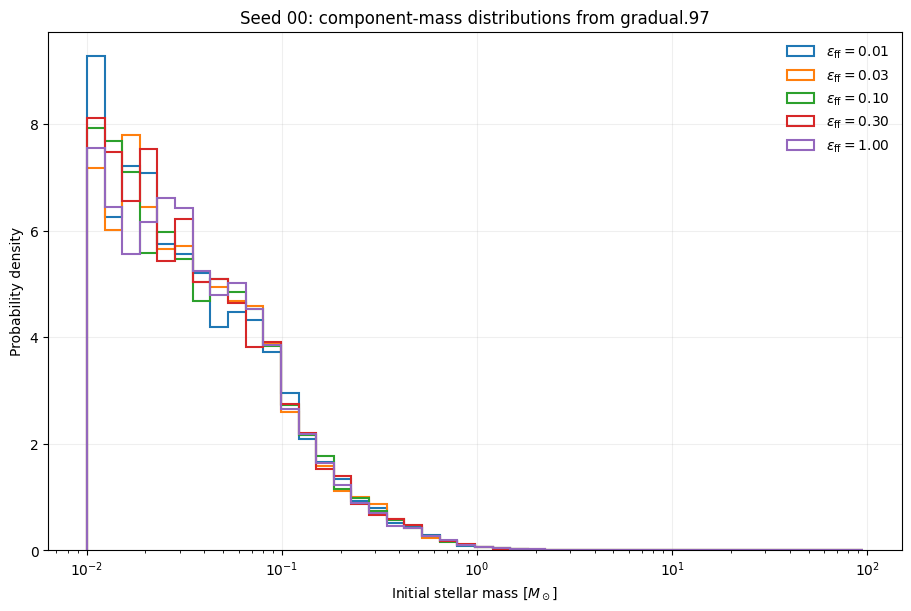

In [13]:
all_masses = np.concatenate([
    df["initial_mass"].to_numpy(float)
    for df in components_by_eff.values()
])

positive_masses = all_masses[
    all_masses > 0
]

log_edges = np.logspace(
    np.log10(positive_masses.min()),
    np.log10(positive_masses.max()),
    45,
)

fig, ax = plt.subplots(
    figsize=(9.0, 6.0),
    constrained_layout=True,
)

for eff, components in components_by_eff.items():
    masses = components["initial_mass"].to_numpy(float)

    ax.hist(
        masses,
        bins=log_edges,
        histtype="step",
        density=True,
        linewidth=1.5,
        label=rf"$\epsilon_{{\rm ff}}={eff:.2f}$",
    )

ax.set_xscale("log")
ax.set_xlabel(r"Initial stellar mass [$M_\odot$]")
ax.set_ylabel("Probability density")
ax.set_title(
    "Seed 00: component-mass distributions from gradual.97"
)
ax.grid(alpha=0.2)
ax.legend(frameon=False)

finish_figure(
    fig,
    "component_mass_distributions.png",
)

## Cumulative mass distributions

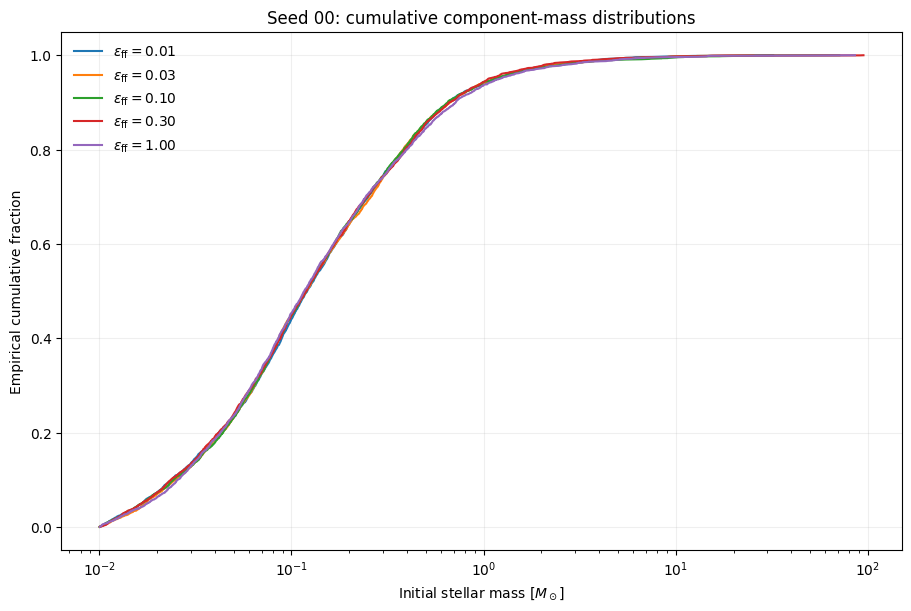

In [14]:
fig, ax = plt.subplots(
    figsize=(9.0, 6.0),
    constrained_layout=True,
)

for eff, components in components_by_eff.items():
    masses = np.sort(
        components["initial_mass"].to_numpy(float)
    )

    y = np.arange(
        1,
        len(masses) + 1,
    ) / len(masses)

    ax.plot(
        masses,
        y,
        lw=1.5,
        label=rf"$\epsilon_{{\rm ff}}={eff:.2f}$",
    )

ax.set_xscale("log")
ax.set_xlabel(r"Initial stellar mass [$M_\odot$]")
ax.set_ylabel("Empirical cumulative fraction")
ax.set_title(
    "Seed 00: cumulative component-mass distributions"
)
ax.grid(alpha=0.2)
ax.legend(frameon=False)

finish_figure(
    fig,
    "component_mass_cdfs.png",
)

## Formation time versus event index

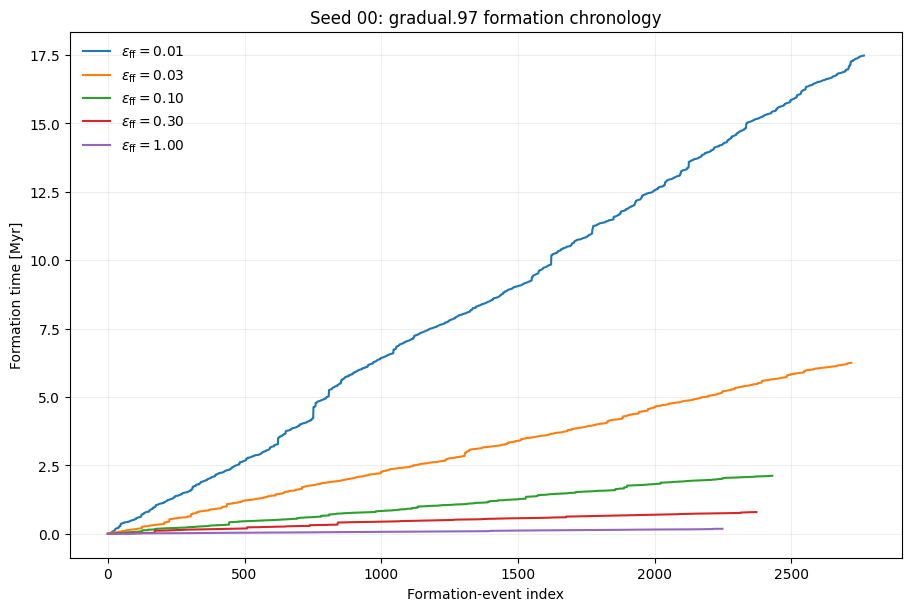

In [15]:
fig, ax = plt.subplots(
    figsize=(9.0, 6.0),
    constrained_layout=True,
)

for eff, events in events_by_eff.items():
    ax.plot(
        events["event_index"],
        events["formation_time_myr"],
        lw=1.5,
        label=rf"$\epsilon_{{\rm ff}}={eff:.2f}$",
    )

ax.set_xlabel("Formation-event index")
ax.set_ylabel("Formation time [Myr]")
ax.set_title(
    "Seed 00: gradual.97 formation chronology"
)
ax.grid(alpha=0.2)
ax.legend(frameon=False)

finish_figure(
    fig,
    "formation_time_vs_event_index.png",
)

## epsilon_ff * formation time versus event index

If the only change were an exact t_form proportional to 1/epsilon_ff
rescaling, these curves would collapse onto one another.

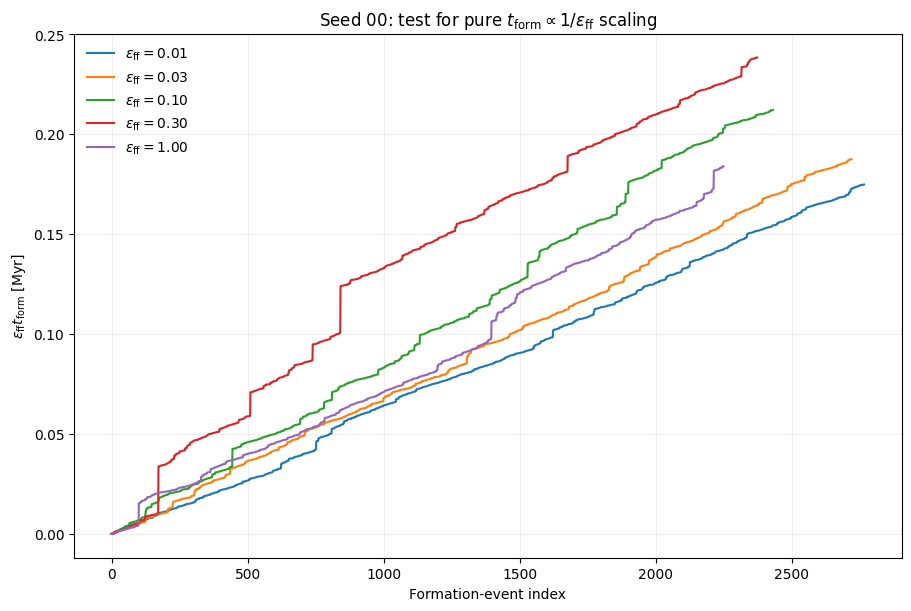

In [16]:
fig, ax = plt.subplots(
    figsize=(9.0, 6.0),
    constrained_layout=True,
)

for eff, events in events_by_eff.items():
    ax.plot(
        events["event_index"],
        eff * events["formation_time_myr"],
        lw=1.5,
        label=rf"$\epsilon_{{\rm ff}}={eff:.2f}$",
    )

ax.set_xlabel("Formation-event index")
ax.set_ylabel(
    r"$\epsilon_{\rm ff} t_{\rm form}$ [Myr]"
)
ax.set_title(
    r"Seed 00: test for pure $t_{\rm form}\propto1/\epsilon_{\rm ff}$ scaling"
)
ax.grid(alpha=0.2)
ax.legend(frameon=False)

finish_figure(
    fig,
    "epsilon_times_formation_time.png",
)

## Cumulative stellar mass introduced versus formation time

This is useful physically: it compares the actual star-formation histories,
regardless of whether the underlying stars are the same realization.

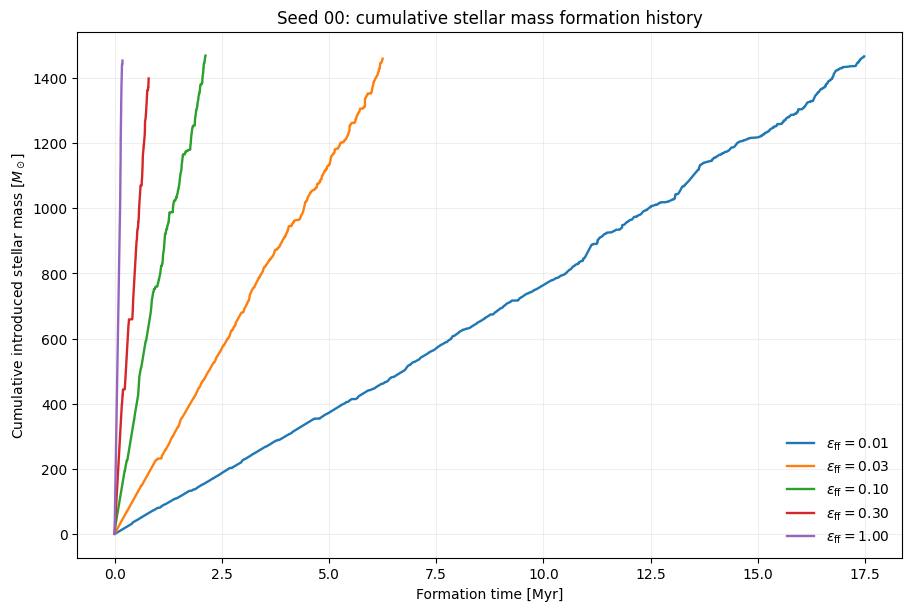

In [17]:
fig, ax = plt.subplots(
    figsize=(9.0, 6.0),
    constrained_layout=True,
)

for eff, events in events_by_eff.items():
    ordered = events.sort_values(
        ["formation_time_myr", "event_index"],
        kind="stable",
    )

    cumulative_mass = np.cumsum(
        ordered["system_mass"].to_numpy(float)
    )

    ax.plot(
        ordered["formation_time_myr"],
        cumulative_mass,
        lw=1.7,
        label=rf"$\epsilon_{{\rm ff}}={eff:.2f}$",
    )

ax.set_xlabel("Formation time [Myr]")
ax.set_ylabel(
    r"Cumulative introduced stellar mass [$M_\odot$]"
)
ax.set_title(
    "Seed 00: cumulative stellar mass formation history"
)
ax.grid(alpha=0.2)
ax.legend(frameon=False)

finish_figure(
    fig,
    "cumulative_stellar_mass_vs_time.png",
)

## Normalized cumulative stellar mass

Dividing by each run's own final stellar mass shows whether the shape of the
star-formation history is similar even when the final masses differ.

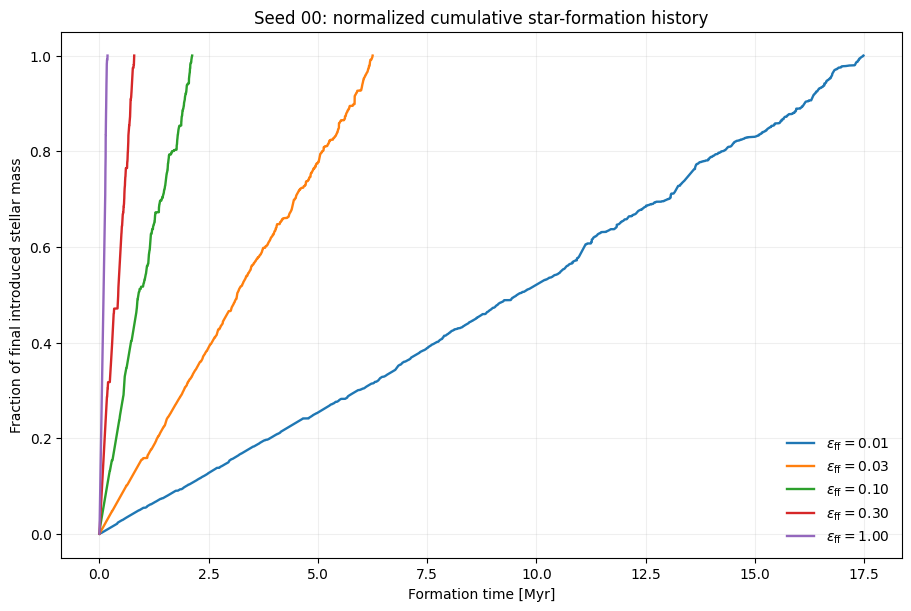

In [18]:
fig, ax = plt.subplots(
    figsize=(9.0, 6.0),
    constrained_layout=True,
)

for eff, events in events_by_eff.items():
    ordered = events.sort_values(
        ["formation_time_myr", "event_index"],
        kind="stable",
    )

    cumulative_mass = np.cumsum(
        ordered["system_mass"].to_numpy(float)
    )

    normalized = (
        cumulative_mass
        / cumulative_mass[-1]
    )

    ax.plot(
        ordered["formation_time_myr"],
        normalized,
        lw=1.7,
        label=rf"$\epsilon_{{\rm ff}}={eff:.2f}$",
    )

ax.set_xlabel("Formation time [Myr]")
ax.set_ylabel("Fraction of final introduced stellar mass")
ax.set_title(
    "Seed 00: normalized cumulative star-formation history"
)
ax.grid(alpha=0.2)
ax.legend(frameon=False)

finish_figure(
    fig,
    "normalized_cumulative_stellar_mass_vs_time.png",
)

## Formation-time comparison for shared NAME values

Even if the complete populations differ, stars with the same NAME may have
comparable formation-time mappings.  We therefore compare formation times
after joining by NAME rather than by event index.

In [19]:
shared_time_rows = []
shared_time_detail_tables = []

for eff, components in components_by_eff.items():
    target_unique = unique_component_view(components)

    merged = (
        reference_unique[
            [
                "formation_time_myr",
                "initial_mass",
                "event_index",
            ]
        ]
        .add_suffix("_ref")
        .join(
            target_unique[
                [
                    "formation_time_myr",
                    "initial_mass",
                    "event_index",
                ]
            ].add_suffix("_target"),
            how="inner",
        )
        .reset_index()
    )

    good = (
        np.isfinite(merged["formation_time_myr_ref"])
        & np.isfinite(merged["formation_time_myr_target"])
    )

    matched = merged[good].copy()

    if len(matched) >= 2:
        x = matched["formation_time_myr_ref"].to_numpy(float)
        y = matched["formation_time_myr_target"].to_numpy(float)

        slope, intercept = np.polyfit(x, y, 1)

        y_fit = intercept + slope * x

        ss_res = np.sum((y - y_fit) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)

        r2 = (
            1.0 - ss_res / ss_tot
            if ss_tot > 0
            else np.nan
        )

        expected_slope = REFERENCE_EFF / eff

        shared_time_rows.append({
            "epsilon_ff": eff,
            "n_shared_names": len(matched),
            "linear_slope": float(slope),
            "linear_intercept_myr": float(intercept),
            "linear_r2": float(r2),
            "expected_inverse_epsilon_slope": float(
                expected_slope
            ),
            "slope_over_inverse_epsilon_expectation": float(
                slope / expected_slope
            ),
            "rms_linear_residual_myr": float(
                np.sqrt(
                    np.mean(
                        (y - y_fit) ** 2
                    )
                )
            ),
        })

        matched["linear_fit_time_myr"] = y_fit
        matched["linear_residual_myr"] = y - y_fit

    else:
        shared_time_rows.append({
            "epsilon_ff": eff,
            "n_shared_names": len(matched),
            "linear_slope": np.nan,
            "linear_intercept_myr": np.nan,
            "linear_r2": np.nan,
            "expected_inverse_epsilon_slope": (
                REFERENCE_EFF / eff
            ),
            "slope_over_inverse_epsilon_expectation": np.nan,
            "rms_linear_residual_myr": np.nan,
        })

    matched.insert(
        0,
        "target_epsilon_ff",
        eff,
    )
    shared_time_detail_tables.append(matched)

df_shared_time = pd.DataFrame(
    shared_time_rows
)

df_shared_time_details = pd.concat(
    shared_time_detail_tables,
    ignore_index=True,
)

print("\nFORMATION-TIME MAPPING FOR SHARED NAME VALUES")
show_table(df_shared_time)

df_shared_time.to_csv(
    OUTPUT_DIR / "shared_name_time_scaling.csv",
    index=False,
)

df_shared_time_details.to_csv(
    OUTPUT_DIR / "shared_name_time_scaling_details.csv",
    index=False,
)


FORMATION-TIME MAPPING FOR SHARED NAME VALUES


,epsilon_ff,n_shared_names,linear_slope,linear_intercept_myr,linear_r2,expected_inverse_epsilon_slope,slope_over_inverse_epsilon_expectation,rms_linear_residual_myr
0,0.01,4083,2.788452,-2.252016e-01,0.997261,3.00,0.929484,2.655799e-01
1,0.03,4083,1.000000,2.412179e-16,1.000000,1.00,1.000000,2.587225e-15
2,0.10,3646,0.391805,-3.133534e-02,0.996722,0.30,1.306016,3.625615e-02
3,0.30,3558,0.142924,6.241006e-02,0.971214,0.10,1.429236,3.866585e-02
4,1.00,3372,0.033853,-6.597980e-04,0.989813,0.03,1.128425,5.090745e-03


## Shared-NAME formation-time plots

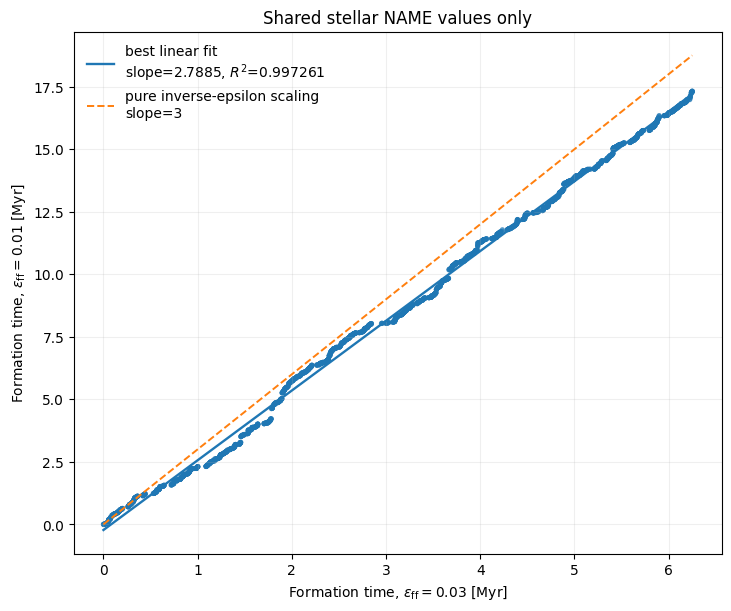

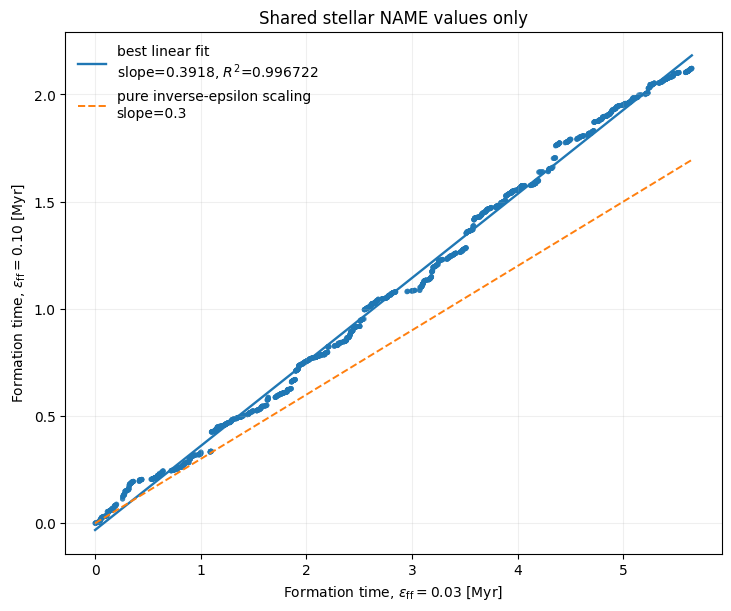

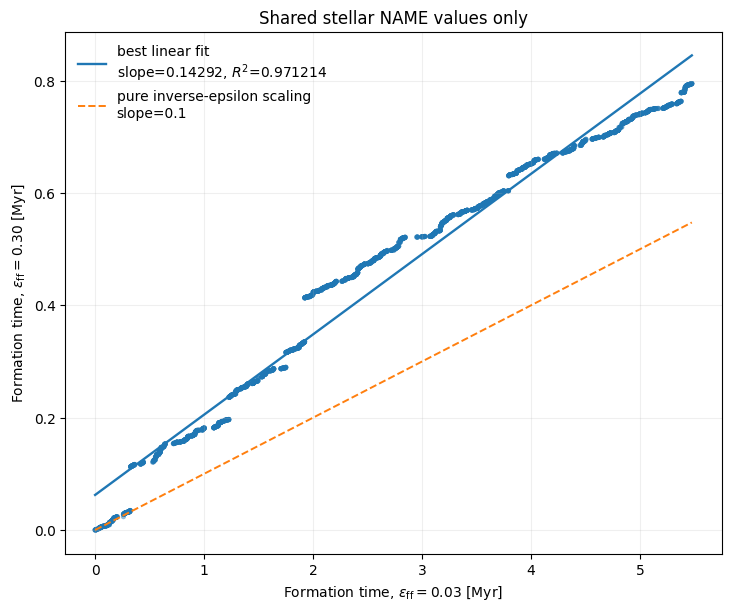

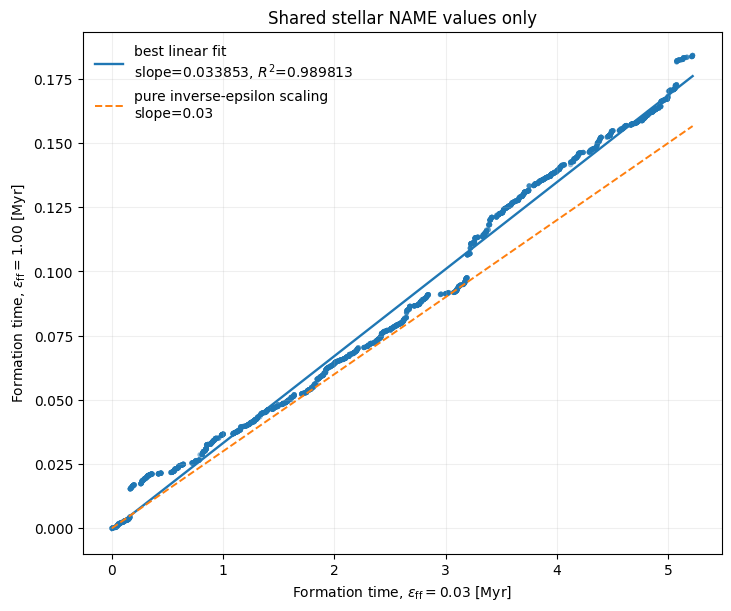

In [20]:
for eff in EFF_DIRS:
    if math.isclose(
        eff,
        REFERENCE_EFF,
    ):
        continue

    sub = df_shared_time_details[
        np.isclose(
            df_shared_time_details["target_epsilon_ff"],
            eff,
        )
    ]

    if len(sub) < 2:
        continue

    x = sub["formation_time_myr_ref"].to_numpy(float)
    y = sub["formation_time_myr_target"].to_numpy(float)

    row = df_shared_time[
        np.isclose(
            df_shared_time["epsilon_ff"],
            eff,
        )
    ].iloc[0]

    fig, ax = plt.subplots(
        figsize=(7.2, 6.0),
        constrained_layout=True,
    )

    ax.scatter(
        x,
        y,
        s=14,
        alpha=0.5,
        edgecolors="none",
    )

    xx = np.linspace(
        min(0.0, x.min()),
        x.max(),
        300,
    )

    ax.plot(
        xx,
        row["linear_intercept_myr"]
        + row["linear_slope"] * xx,
        lw=1.7,
        label=(
            "best linear fit\n"
            f"slope={row['linear_slope']:.5g}, "
            f"$R^2$={row['linear_r2']:.6f}"
        ),
    )

    expected = REFERENCE_EFF / eff

    ax.plot(
        xx,
        expected * xx,
        ls="--",
        lw=1.4,
        label=(
            "pure inverse-epsilon scaling\n"
            f"slope={expected:.5g}"
        ),
    )

    ax.set_xlabel(
        r"Formation time, $\epsilon_{\rm ff}=0.03$ [Myr]"
    )
    ax.set_ylabel(
        rf"Formation time, $\epsilon_{{\rm ff}}={eff:.2f}$ [Myr]"
    )
    ax.set_title(
        "Shared stellar NAME values only"
    )
    ax.grid(alpha=0.2)
    ax.legend(frameon=False)

    finish_figure(
        fig,
        f"shared_name_time_mapping_eff{eff:.2f}.png",
    )

## Compact final interpretation table

This table separates three questions:

A. SAME REALIZATION?
   Same component NAME set, masses, binaries, and formation-event sequence.

B. SAME POPULATION STATISTICS?
   Not necessarily the same stars, but similar number of components, total
   mass, and IMF-like mass distribution.

C. SAME TIMING UP TO RESCALING?
   Shared NAME values follow a tight time mapping.

The script reports the diagnostics rather than imposing a statistical
threshold for "similar IMF".

In [21]:
final_rows = []

for eff in EFF_DIRS:
    names = df_name_sets.loc[
        np.isclose(
            df_name_sets["epsilon_ff"],
            eff,
        )
    ].iloc[0]

    components = df_component_match.loc[
        np.isclose(
            df_component_match["epsilon_ff"],
            eff,
        )
    ].iloc[0]

    events = df_event_summary.loc[
        np.isclose(
            df_event_summary["epsilon_ff"],
            eff,
        )
    ].iloc[0]

    mass_dist = df_mass_distributions.loc[
        np.isclose(
            df_mass_distributions["epsilon_ff"],
            eff,
        )
    ].iloc[0]

    exact_same_realization = bool(
        names["same_name_set"]
        and np.isclose(
            components["fraction_shared_masses_matching"],
            1.0,
        )
        and np.isclose(
            components["fraction_shared_roles_matching"],
            1.0,
        )
        and np.isclose(
            components[
                "fraction_shared_binary_partners_matching"
            ],
            1.0,
        )
        and events["same_event_count"]
        and np.isclose(
            events[
                "fraction_exact_events_matching_in_common_range"
            ],
            1.0,
        )
    )

    final_rows.append({
        "epsilon_ff": eff,
        "same_name_set": bool(
            names["same_name_set"]
        ),
        "name_jaccard_similarity": float(
            names["jaccard_name_similarity"]
        ),
        "fraction_shared_masses_matching": float(
            components["fraction_shared_masses_matching"]
        ),
        "fraction_shared_binary_partners_matching": float(
            components[
                "fraction_shared_binary_partners_matching"
            ]
        ),
        "same_event_count": bool(
            events["same_event_count"]
        ),
        "fraction_exact_events_matching": float(
            events[
                "fraction_exact_events_matching_in_common_range"
            ]
        ),
        "identical_prefix_length": int(
            events["identical_prefix_length"]
        ),
        "empirical_ks_mass_distance_vs_eff003": float(
            mass_dist[
                "empirical_ks_distance_vs_eff003"
            ]
        ),
        "exact_same_realization": exact_same_realization,
    })

df_final = pd.DataFrame(final_rows)

print("\n" + "=" * 80)
print("FINAL DIRECT gradual.97 DIAGNOSTIC")
print("=" * 80)

show_table(df_final)

df_final.to_csv(
    OUTPUT_DIR / "final_gradual97_diagnostic.csv",
    index=False,
)


FINAL DIRECT gradual.97 DIAGNOSTIC


,epsilon_ff,same_name_set,name_jaccard_similarity,fraction_shared_masses_matching,fraction_shared_binary_partners_matching,same_event_count,fraction_exact_events_matching,identical_prefix_length,empirical_ks_mass_distance_vs_eff003,exact_same_realization
0,0.01,False,0.986232,0.0,0.338232,False,0.0,0,0.016906,False
1,0.03,True,1.000000,1.0,1.000000,True,1.0,2720,0.000000,True
2,0.10,False,0.892971,0.0,0.344487,False,0.0,0,0.013673,False
3,0.30,False,0.871418,0.0,0.348229,False,0.0,0,0.015904,False
4,1.00,False,0.825863,0.0,0.321174,False,0.0,0,0.016149,False


## Text verdict

In [22]:
non_reference = df_final[
    ~np.isclose(
        df_final["epsilon_ff"],
        REFERENCE_EFF,
    )
]

if non_reference["exact_same_realization"].all():
    print(
        "\nRESULT: All epsilon_ff runs contain the same stellar "
        "realization in gradual.97; only their formation chronology differs."
    )

else:
    print(
        "\nRESULT: At least one epsilon_ff run does NOT contain the "
        "same exact gradual.97 stellar realization as epsilon_ff=0.03."
    )

    print(
        "\nThis conclusion is based only on formation-file quantities, "
        "so stellar-wind mass loss and later dynamical evolution cannot "
        "explain the mismatch."
    )

    print(
        "\nUse the following outputs to determine how different the "
        "realizations actually are:"
    )

    print(
        "  - name_set_comparison.csv"
    )
    print(
        "  - shared_component_comparison.csv"
    )
    print(
        "  - event_order_comparison.csv"
    )
    print(
        "  - mass_distribution_summary.csv"
    )
    print(
        "  - shared_name_time_scaling.csv"
    )

print(
    f"\nOutputs written to: {OUTPUT_DIR.resolve()}"
)


RESULT: At least one epsilon_ff run does NOT contain the same exact gradual.97 stellar realization as epsilon_ff=0.03.

This conclusion is based only on formation-file quantities, so stellar-wind mass loss and later dynamical evolution cannot explain the mismatch.

Use the following outputs to determine how different the realizations actually are:
  - name_set_comparison.csv
  - shared_component_comparison.csv
  - event_order_comparison.csv
  - mass_distribution_summary.csv
  - shared_name_time_scaling.csv

Outputs written to: /sfs/gpfs/tardis/home/wyz5rge/synthetic-cmd-dev/notebooks/2026/08-06_compare-seeds-across-e_ff/iteration2/seed00_gradual_comparison_outputs
